# 02c — Spatial Analysis: Maps, Density & Transport Deserts

**Purpose:** Visualize the geographic dimension of bus coverage and deprivation.
Policy makers think spatially — they need to SEE where the gaps are, not just
count them.

**Sections:**
1. Stop density map — where are the bus stops?
2. Deprivation map — IMD decile choropleth
3. Stop density vs deprivation overlay
4. Transport desert identification
5. Regional comparison maps
6. Urban vs rural spatial patterns

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RAW = Path('/Users/souravamseekarmarti/Projects/aequitas/data/raw')
AUDIT = Path('/Users/souravamseekarmarti/Projects/aequitas/data/audit')

print("Loading spatial data...")

Loading spatial data...


In [2]:
# Load LSOA boundaries
lsoa_gdf = gpd.read_file(RAW / 'boundaries' / 'lsoa_2021_england_buc.geojson')
region_gdf = gpd.read_file(RAW / 'boundaries' / 'regions_2021_england_buc.geojson')

# Identify code and name columns
lsoa_code_col = [c for c in lsoa_gdf.columns if 'cd' in c.lower() or 'code' in c.lower()][0]
lsoa_name_col = [c for c in lsoa_gdf.columns if 'nm' in c.lower() or 'name' in c.lower()][0]
region_code_col = [c for c in region_gdf.columns if 'cd' in c.lower() or 'code' in c.lower()][0]
region_name_col = [c for c in region_gdf.columns if 'nm' in c.lower() or 'name' in c.lower()][0]

print(f"LSOA boundaries: {len(lsoa_gdf):,} ({lsoa_code_col}, {lsoa_name_col})")
print(f"Region boundaries: {len(region_gdf):,} ({region_code_col}, {region_name_col})")
print(f"LSOA CRS: {lsoa_gdf.crs}")
print(f"Regions: {region_gdf[region_name_col].tolist()}")

LSOA boundaries: 33,755 (LSOA21CD, LSOA21NM)
Region boundaries: 9 (RGN22CD, RGN22NM)
LSOA CRS: EPSG:4326
Regions: ['North East', 'North West', 'Yorkshire and The Humber', 'East Midlands', 'West Midlands', 'East of England', 'London', 'South East', 'South West']


In [3]:
# Load NaPTAN stops — England active bus stops only
naptan = pd.read_csv(RAW / 'naptan' / 'Stops.csv', low_memory=False)
england_bus = naptan[
    (naptan['ATCOCode'].str.match(r'^[0-4]')) &
    (naptan['StopType'].isin(['BCT', 'BCS', 'BCE'])) &
    (naptan['Status'] == 'act')
].copy()

# Drop stops with null coordinates
has_coords = england_bus[['Easting', 'Northing']].notna().all(axis=1)
stops_with_coords = england_bus[has_coords].copy()
print(f"England active bus stops: {len(england_bus):,}")
print(f"With valid coordinates: {len(stops_with_coords):,}")

# Convert to GeoDataFrame (EPSG:27700 — British National Grid)
stops_gdf = gpd.GeoDataFrame(
    stops_with_coords,
    geometry=gpd.points_from_xy(stops_with_coords['Easting'], stops_with_coords['Northing']),
    crs='EPSG:27700'
)

del naptan, england_bus
print(f"Stops GeoDataFrame: {len(stops_gdf):,} points in EPSG:27700")

England active bus stops: 0
With valid coordinates: 0
Stops GeoDataFrame: 0 points in EPSG:27700


In [4]:
# Load IMD for deprivation overlay
imd = pd.read_csv(RAW / 'imd' / 'imd2025_all_ranks_scores_deciles.csv')
imd_code_col = [c for c in imd.columns if 'LSOA' in c and 'code' in c.lower()][0]
imd_score_col = [c for c in imd.columns if 'IMD' in c and 'Score' in c and 'Rank' not in c][0]
imd_decile_col = [c for c in imd.columns if 'IMD' in c and 'Decile' in c][0]
print(f"IMD: {len(imd):,} LSOAs, key columns: {imd_code_col}, {imd_score_col}, {imd_decile_col}")

IMD: 33,755 LSOAs, key columns: LSOA code (2021), Index of Multiple Deprivation (IMD) Score, Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)


## 1. Bus Stop Density Map — England Overview

In [5]:
# Ensure everything is in EPSG:27700 for spatial operations
if lsoa_gdf.crs.to_epsg() != 27700:
    lsoa_gdf = lsoa_gdf.to_crs('EPSG:27700')
if region_gdf.crs.to_epsg() != 27700:
    region_gdf = region_gdf.to_crs('EPSG:27700')

# Spatial join: stops → LSOA
print("Performing spatial join (stops → LSOA)...")
stops_in_lsoa = gpd.sjoin(stops_gdf, lsoa_gdf[[lsoa_code_col, 'geometry']], how='left', predicate='within')
stop_counts = stops_in_lsoa.groupby(lsoa_code_col).size().reset_index(name='stop_count')

# Join stop counts to LSOA boundaries
lsoa_with_stops = lsoa_gdf.merge(stop_counts, on=lsoa_code_col, how='left')
lsoa_with_stops['stop_count'] = lsoa_with_stops['stop_count'].fillna(0).astype(int)

print(f"LSOAs with ≥1 stop: {(lsoa_with_stops['stop_count'] > 0).sum():,}")
print(f"LSOAs with 0 stops: {(lsoa_with_stops['stop_count'] == 0).sum():,}")
print(f"Mean stops per LSOA: {lsoa_with_stops['stop_count'].mean():.1f}")
print(f"Max stops in single LSOA: {lsoa_with_stops['stop_count'].max()}")

Performing spatial join (stops → LSOA)...
LSOAs with ≥1 stop: 0
LSOAs with 0 stops: 33,755
Mean stops per LSOA: 0.0
Max stops in single LSOA: 0


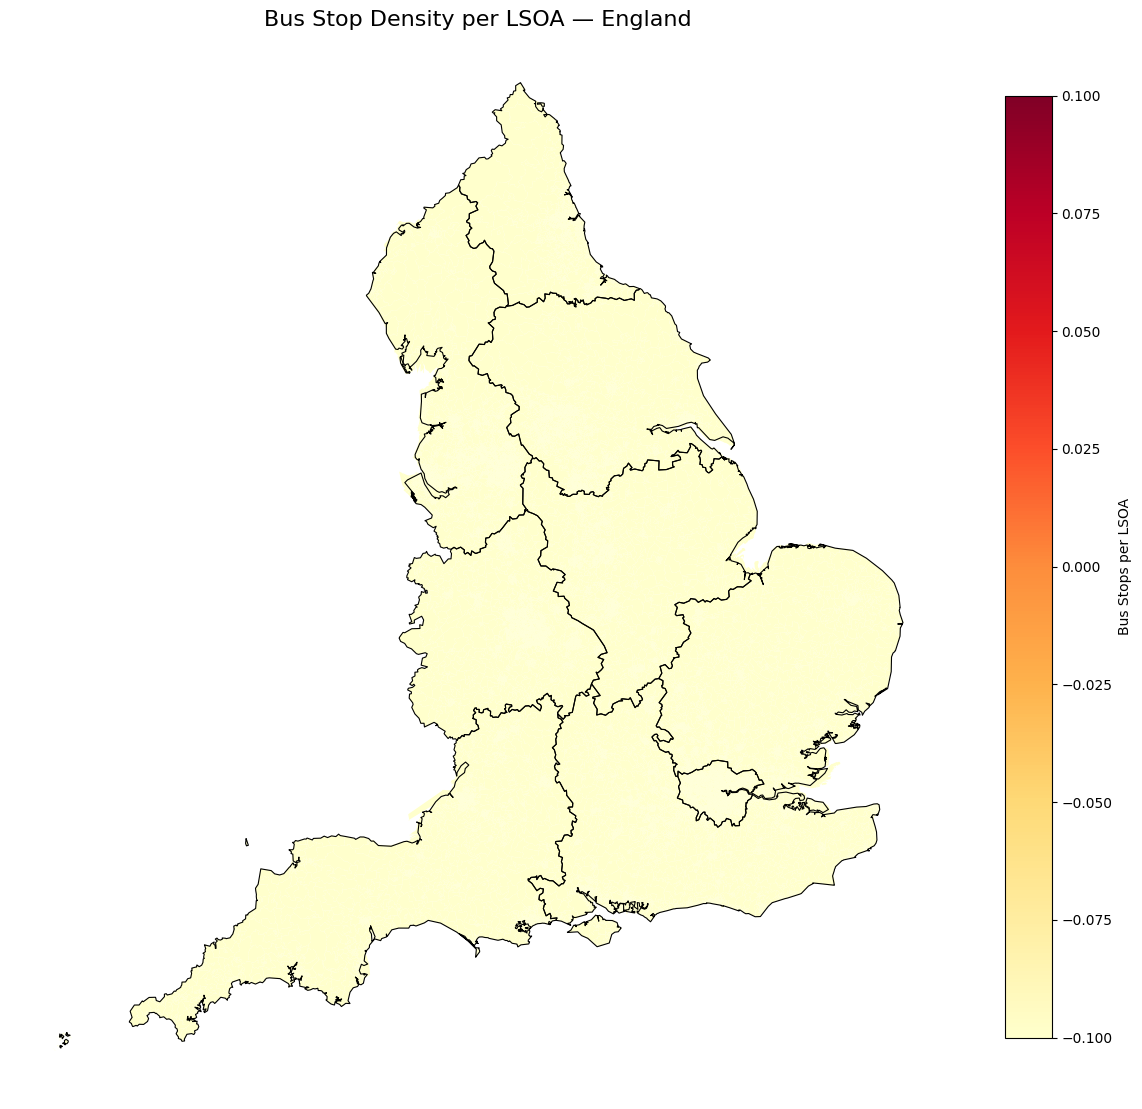

In [6]:
# Map 1: Stop density choropleth
fig, ax = plt.subplots(1, 1, figsize=(12, 16))
lsoa_with_stops.plot(
    column='stop_count',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Bus Stops per LSOA', 'shrink': 0.6},
    cmap='YlOrRd',
    edgecolor='none',
    vmin=0,
    vmax=lsoa_with_stops['stop_count'].quantile(0.95),
    missing_kwds={'color': 'lightgray'}
)
region_gdf.boundary.plot(ax=ax, linewidth=0.8, color='black')
ax.set_title('Bus Stop Density per LSOA — England', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 2. IMD Deprivation Map

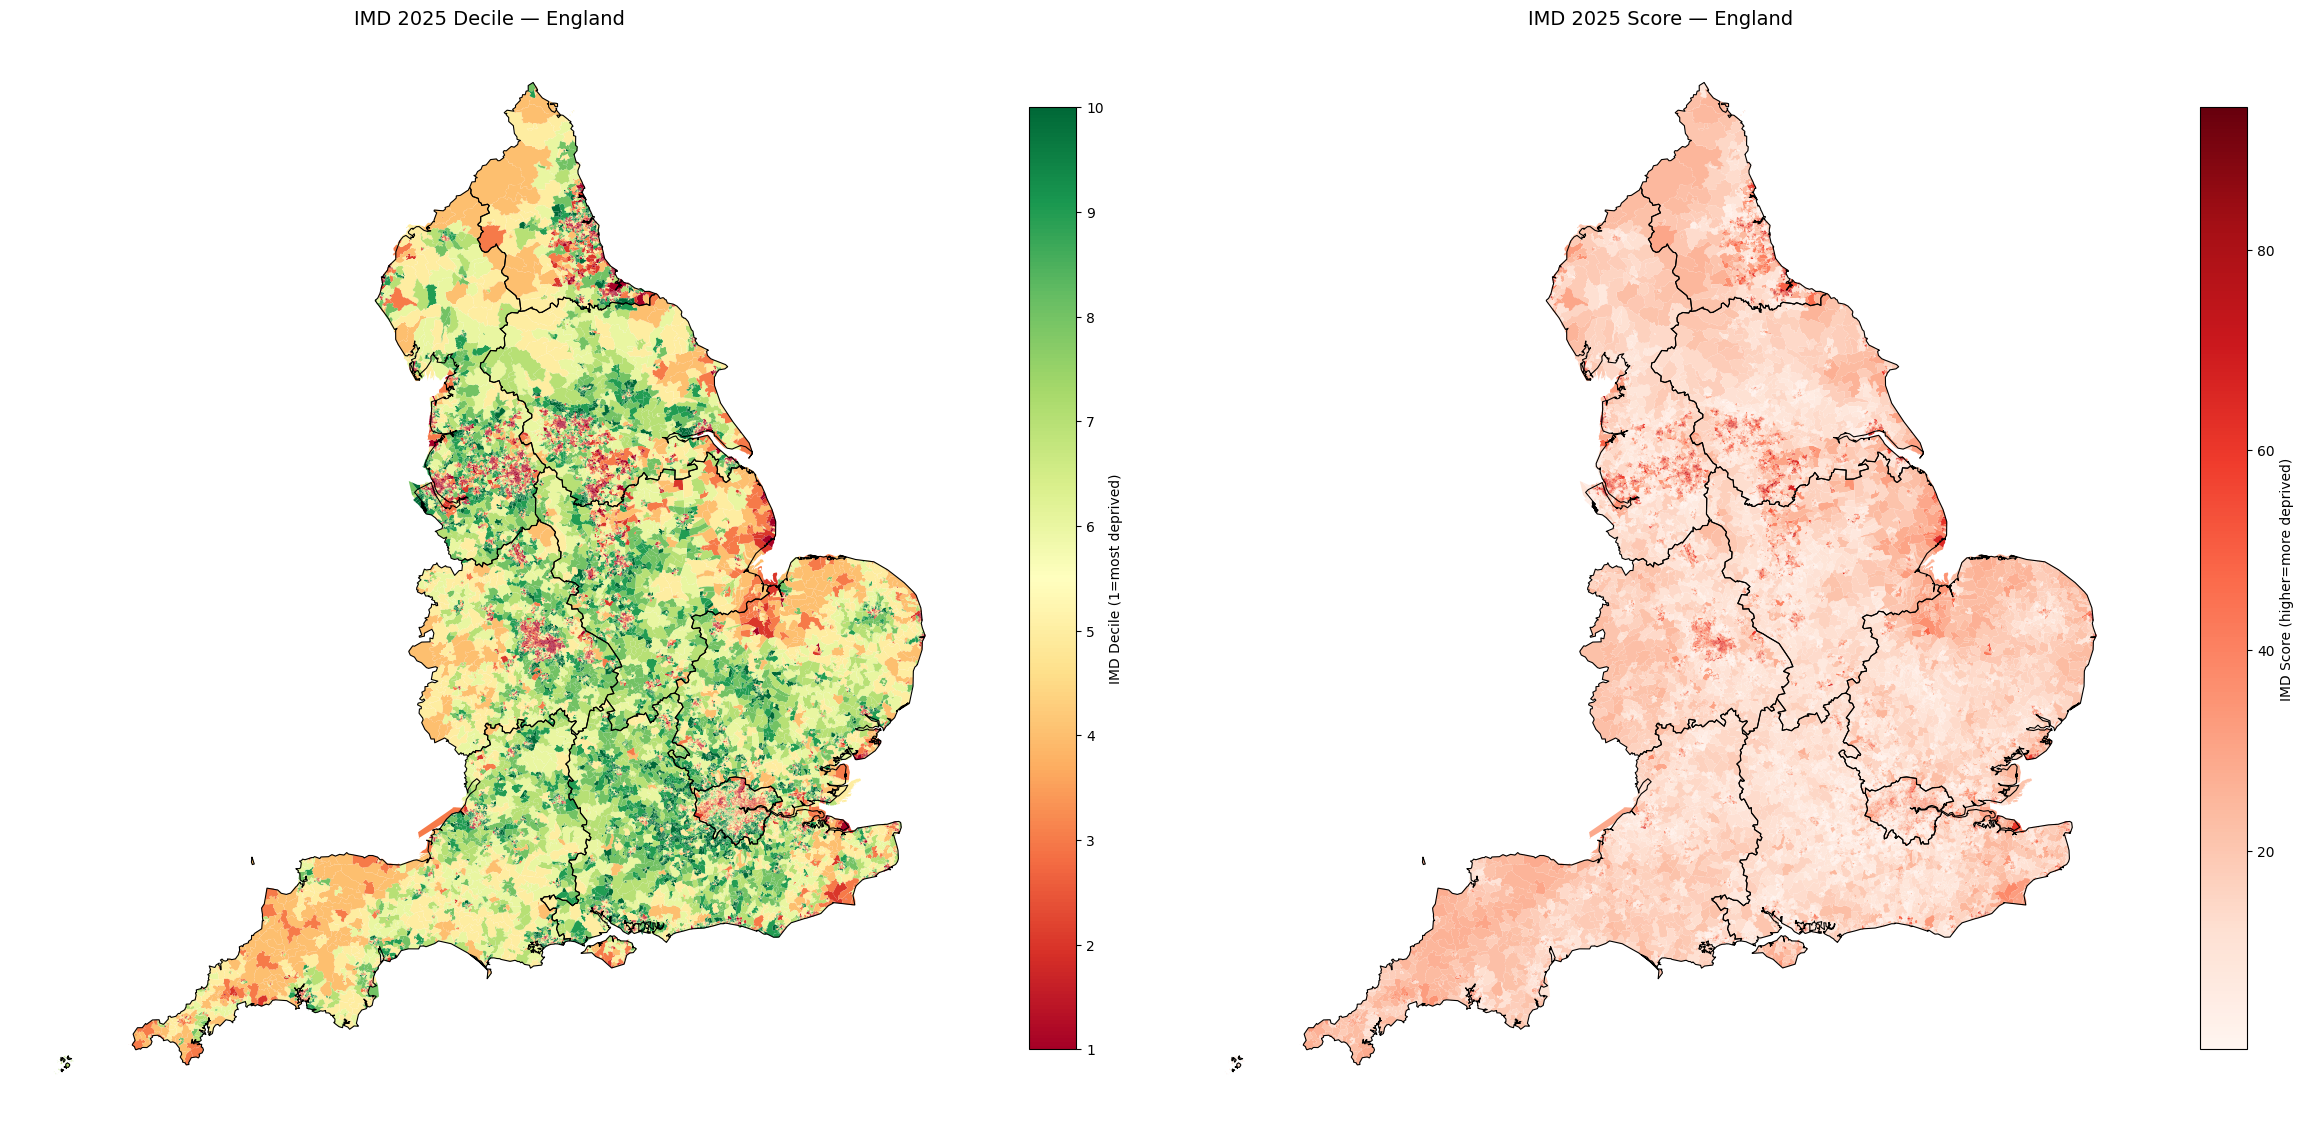

In [7]:
# Join IMD to LSOA boundaries
lsoa_imd = lsoa_gdf.merge(imd[[imd_code_col, imd_score_col, imd_decile_col]],
                            left_on=lsoa_code_col, right_on=imd_code_col, how='left')

fig, axes = plt.subplots(1, 2, figsize=(24, 16))

# Decile map (1=most deprived, 10=least deprived)
lsoa_imd.plot(
    column=imd_decile_col,
    ax=axes[0],
    legend=True,
    legend_kwds={'label': 'IMD Decile (1=most deprived)', 'shrink': 0.6},
    cmap='RdYlGn',
    edgecolor='none'
)
region_gdf.boundary.plot(ax=axes[0], linewidth=0.8, color='black')
axes[0].set_title('IMD 2025 Decile — England', fontsize=14)
axes[0].set_axis_off()

# Score map (higher = more deprived)
lsoa_imd.plot(
    column=imd_score_col,
    ax=axes[1],
    legend=True,
    legend_kwds={'label': 'IMD Score (higher=more deprived)', 'shrink': 0.6},
    cmap='Reds',
    edgecolor='none'
)
region_gdf.boundary.plot(ax=axes[1], linewidth=0.8, color='black')
axes[1].set_title('IMD 2025 Score — England', fontsize=14)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 3. Stop Density vs Deprivation Overlay

The critical question: do deprived areas have fewer bus stops?

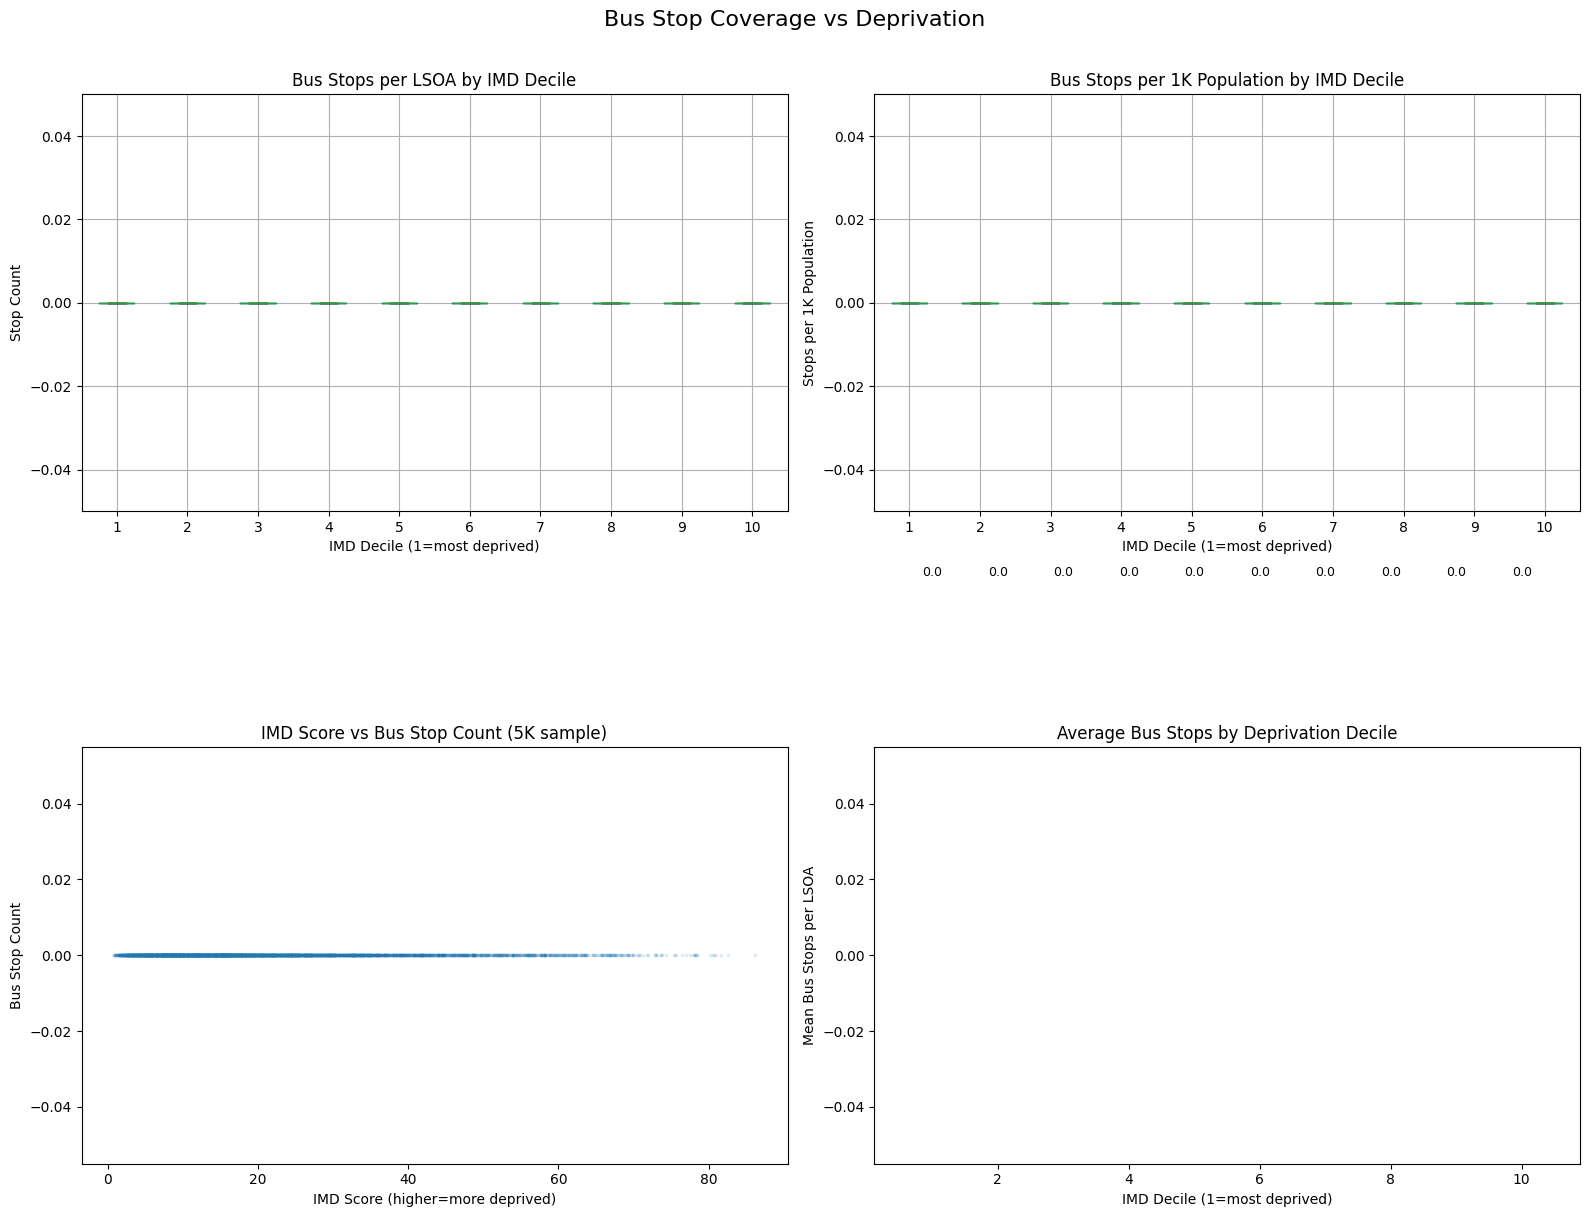

=== Mean Bus Stops by IMD Decile ===
 Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)  mean_stops  mean_stops_per_1k  n_lsoas
                                                                                  1         0.0                0.0     3375
                                                                                  2         0.0                0.0     3376
                                                                                  3         0.0                0.0     3375
                                                                                  4         0.0                0.0     3376
                                                                                  5         0.0                0.0     3375
                                                                                  6         0.0                0.0     3376
                                                                                  7         0.0

In [8]:
# Merge stop counts with IMD
lsoa_combined = lsoa_with_stops.merge(
    imd[[imd_code_col, imd_score_col, imd_decile_col]],
    left_on=lsoa_code_col, right_on=imd_code_col, how='left'
)

# Also add population for per-capita metrics
pop = pd.read_csv(RAW / 'census' / 'census2021_ts001_lsoa_population.csv')
pop_total_col = [c for c in pop.columns if 'Total' in c and 'measures' in c][0]
pop_eng = pop[pop['geography code'].str.startswith('E')]
lsoa_combined = lsoa_combined.merge(
    pop_eng[['geography code', pop_total_col]].rename(columns={pop_total_col: 'population'}),
    left_on=lsoa_code_col, right_on='geography code', how='left'
)
lsoa_combined['stops_per_1k'] = lsoa_combined['stop_count'] / lsoa_combined['population'] * 1000

# Stop count by IMD decile
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plot: stops per LSOA by decile
lsoa_combined.boxplot(column='stop_count', by=imd_decile_col, ax=axes[0, 0])
axes[0, 0].set_title('Bus Stops per LSOA by IMD Decile')
axes[0, 0].set_xlabel('IMD Decile (1=most deprived)')
axes[0, 0].set_ylabel('Stop Count')
axes[0, 0].set_ylim(0, lsoa_combined['stop_count'].quantile(0.95))

# Box plot: stops per 1k population by decile
lsoa_combined.boxplot(column='stops_per_1k', by=imd_decile_col, ax=axes[0, 1])
axes[0, 1].set_title('Bus Stops per 1K Population by IMD Decile')
axes[0, 1].set_xlabel('IMD Decile (1=most deprived)')
axes[0, 1].set_ylabel('Stops per 1K Population')
axes[0, 1].set_ylim(0, lsoa_combined['stops_per_1k'].quantile(0.95))

# Scatter plot: IMD score vs stop count
ax = axes[1, 0]
sample = lsoa_combined.sample(min(5000, len(lsoa_combined)), random_state=42)
ax.scatter(sample[imd_score_col], sample['stop_count'], alpha=0.1, s=3)
ax.set_xlabel('IMD Score (higher=more deprived)')
ax.set_ylabel('Bus Stop Count')
ax.set_title('IMD Score vs Bus Stop Count (5K sample)')

# Mean stops by decile — bar chart
mean_by_decile = lsoa_combined.groupby(imd_decile_col).agg(
    mean_stops=('stop_count', 'mean'),
    mean_stops_per_1k=('stops_per_1k', 'mean'),
    n_lsoas=('stop_count', 'count')
).reset_index()

ax = axes[1, 1]
bars = ax.bar(mean_by_decile[imd_decile_col], mean_by_decile['mean_stops'],
              color=['#d73027' if d <= 3 else '#fee08b' if d <= 7 else '#1a9850' for d in mean_by_decile[imd_decile_col]])
ax.set_xlabel('IMD Decile (1=most deprived)')
ax.set_ylabel('Mean Bus Stops per LSOA')
ax.set_title('Average Bus Stops by Deprivation Decile')
for bar, val in zip(bars, mean_by_decile['mean_stops']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=9)

plt.suptitle('Bus Stop Coverage vs Deprivation', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Print the numbers
print("=== Mean Bus Stops by IMD Decile ===")
print(mean_by_decile.to_string(index=False))

## 4. Transport Deserts — LSOAs with High Need but Low Coverage

A "transport desert" = high deprivation (IMD decile 1-3) + low bus coverage.
We identify these LSOAs and map them.

In [9]:
# Define transport desert: most deprived 30% AND below-median stop coverage
median_stops = lsoa_combined['stop_count'].median()
median_stops_per_1k = lsoa_combined['stops_per_1k'].median()

deserts = lsoa_combined[
    (lsoa_combined[imd_decile_col] <= 3) &  # Most deprived 30%
    (lsoa_combined['stops_per_1k'] < median_stops_per_1k)  # Below median coverage
].copy()

well_served_deprived = lsoa_combined[
    (lsoa_combined[imd_decile_col] <= 3) &
    (lsoa_combined['stops_per_1k'] >= median_stops_per_1k)
].copy()

print(f"=== Transport Desert Identification ===")
print(f"  Median stops per 1K population: {median_stops_per_1k:.2f}")
print(f"  Most deprived LSOAs (decile 1-3): {(lsoa_combined[imd_decile_col] <= 3).sum():,}")
print(f"  Transport deserts (deprived + low coverage): {len(deserts):,}")
print(f"  Well-served deprived areas: {len(well_served_deprived):,}")
print(f"  Desert rate among deprived: {100*len(deserts)/(len(deserts)+len(well_served_deprived)):.1f}%")

=== Transport Desert Identification ===
  Median stops per 1K population: 0.00
  Most deprived LSOAs (decile 1-3): 10,126
  Transport deserts (deprived + low coverage): 0
  Well-served deprived areas: 10,126
  Desert rate among deprived: 0.0%


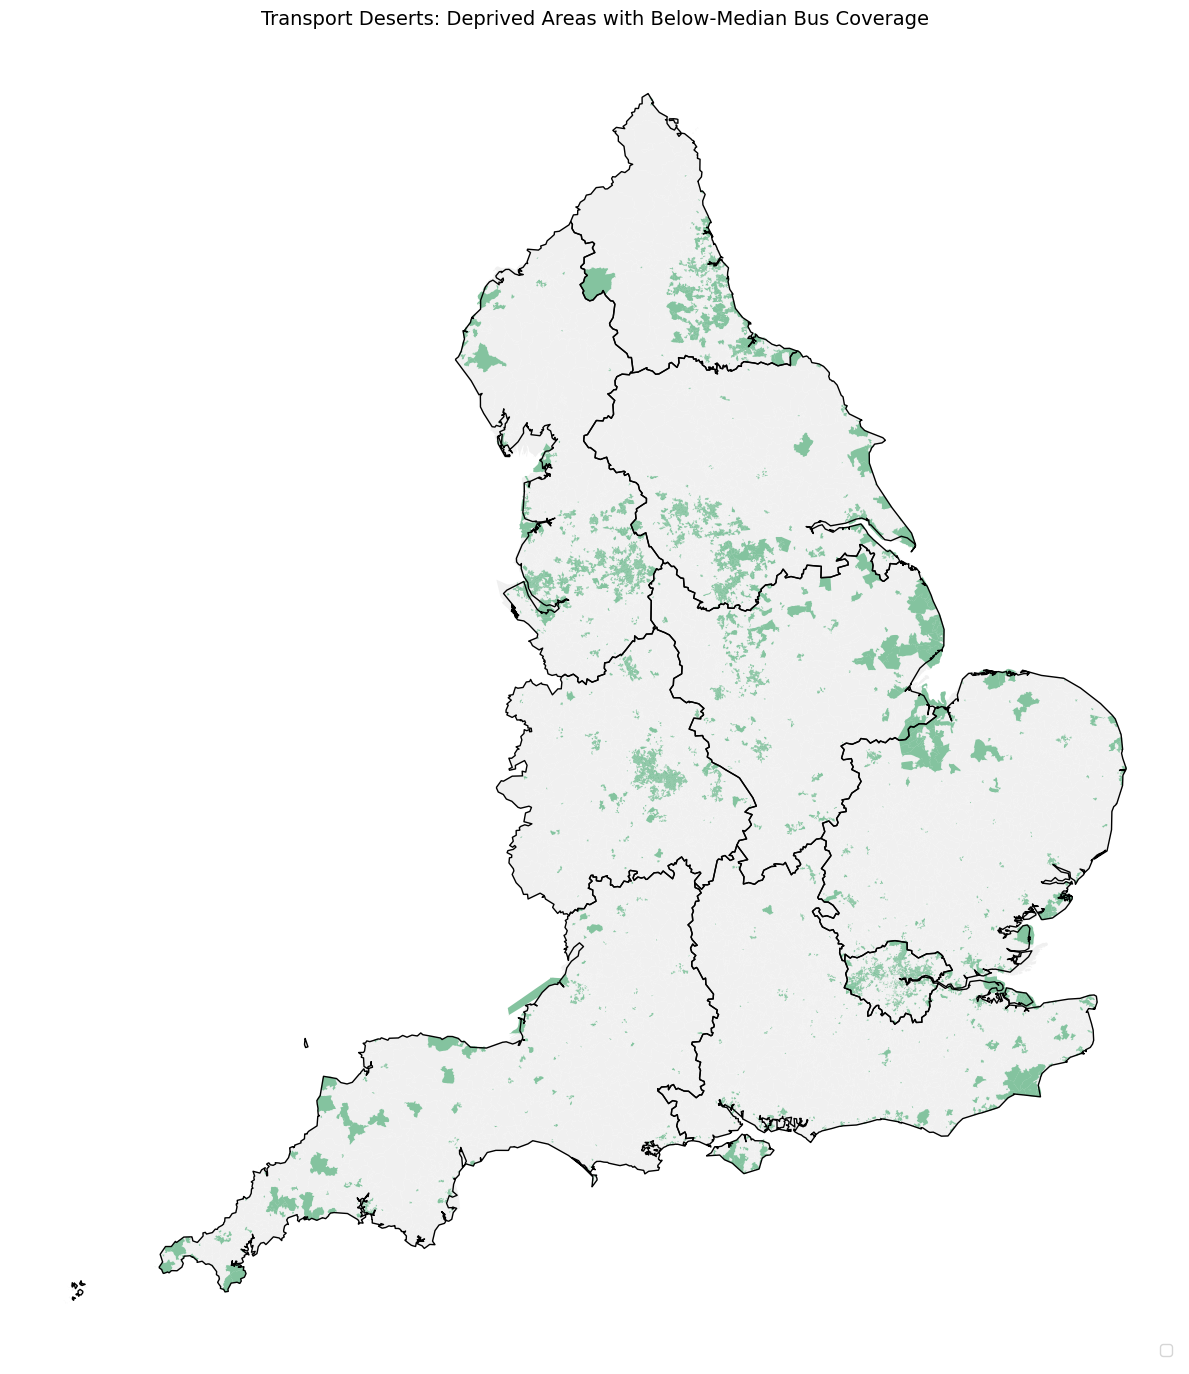

In [10]:
# Map transport deserts
fig, ax = plt.subplots(1, 1, figsize=(12, 16))

# Background: all LSOAs in light gray
lsoa_gdf.plot(ax=ax, color='#f0f0f0', edgecolor='none')

# Highlight transport deserts in red
deserts.plot(ax=ax, color='#d73027', edgecolor='none', alpha=0.8, label='Transport Desert')

# Highlight well-served deprived in green
well_served_deprived.plot(ax=ax, color='#1a9850', edgecolor='none', alpha=0.5, label='Well-served Deprived')

region_gdf.boundary.plot(ax=ax, linewidth=1, color='black')
ax.set_title('Transport Deserts: Deprived Areas with Below-Median Bus Coverage', fontsize=14)
ax.set_axis_off()
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Regional Comparison

In [11]:
# Assign regions to LSOAs via spatial join
lsoa_centroids = lsoa_combined.copy()
lsoa_centroids['centroid'] = lsoa_centroids.geometry.centroid
lsoa_centroids_gdf = gpd.GeoDataFrame(lsoa_centroids, geometry='centroid', crs='EPSG:27700')

lsoa_with_region = gpd.sjoin(lsoa_centroids_gdf, region_gdf[[region_code_col, region_name_col, 'geometry']],
                              how='left', predicate='within')

print("=== Regional Summary ===")
regional = lsoa_with_region.groupby(region_name_col).agg(
    n_lsoas=('stop_count', 'count'),
    mean_stops=('stop_count', 'mean'),
    mean_stops_per_1k=('stops_per_1k', 'mean'),
    median_imd_score=(imd_score_col, 'median'),
    pct_zero_stops=('stop_count', lambda x: (x == 0).mean() * 100),
).sort_values('mean_stops_per_1k', ascending=False)

print(regional.to_string())

=== Regional Summary ===
                          n_lsoas  mean_stops  mean_stops_per_1k  median_imd_score  pct_zero_stops
RGN22NM                                                                                           
East Midlands                2847         0.0                0.0           16.6740           100.0
East of England              3732         0.0                0.0           15.1020           100.0
London                       4969         0.0                0.0           21.3260           100.0
North East                   1676         0.0                0.0           25.2915           100.0
North West                   4494         0.0                0.0           21.6300           100.0
South East                   5523         0.0                0.0           12.8030           100.0
South West                   3381         0.0                0.0           15.4230           100.0
West Midlands                3574         0.0                0.0           20.0350  

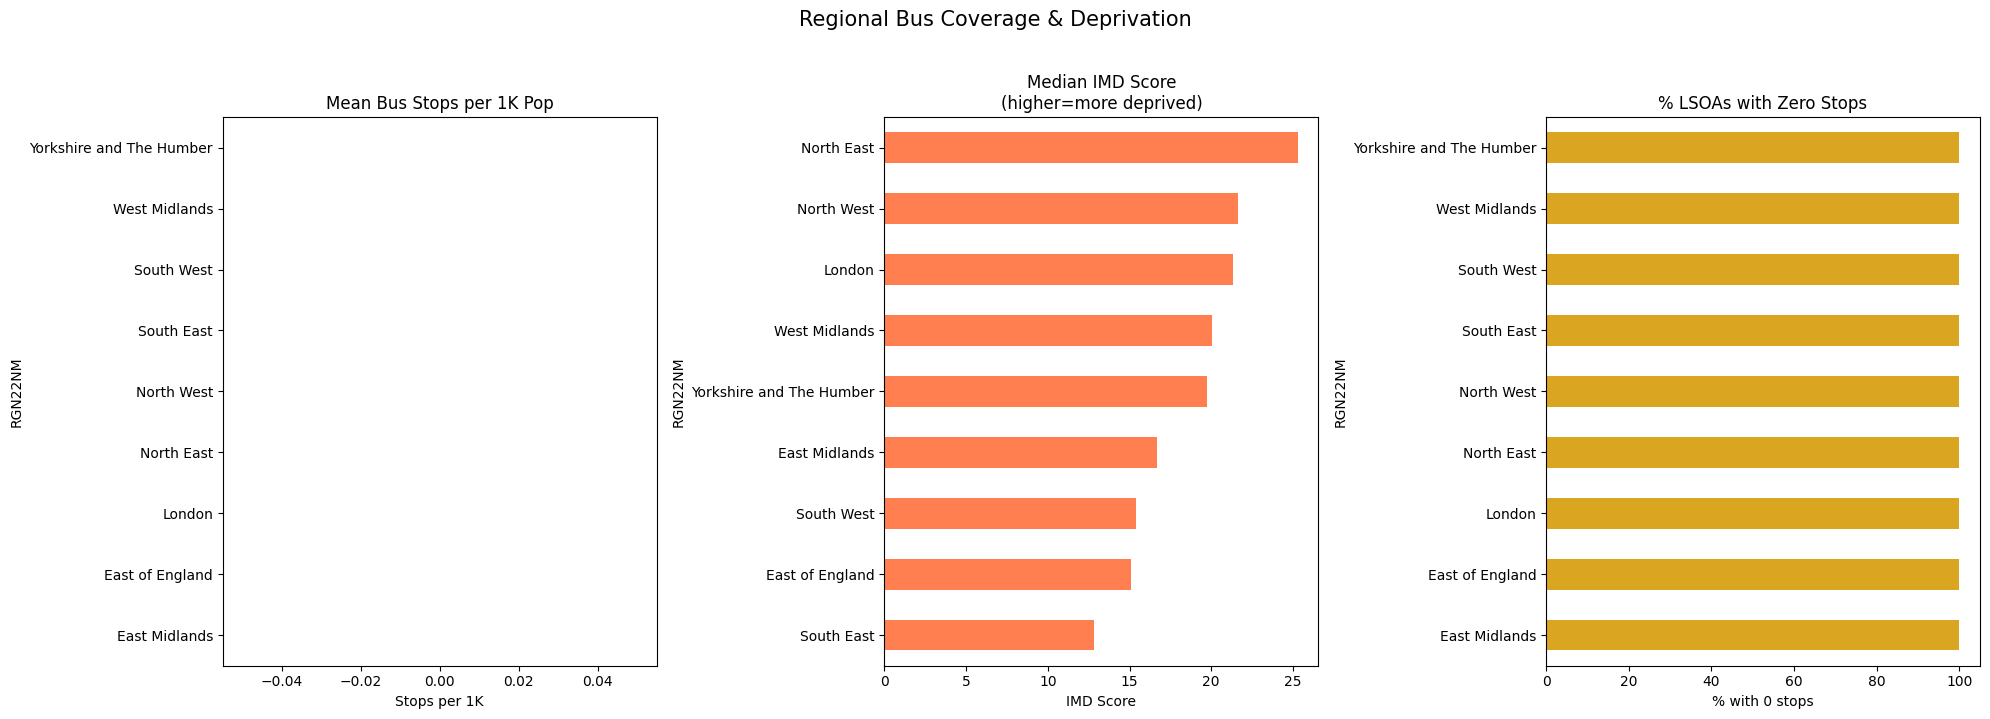

In [12]:
# Regional bar charts
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

regional.sort_values('mean_stops_per_1k').plot(kind='barh', y='mean_stops_per_1k',
                                                 ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Mean Bus Stops per 1K Pop')
axes[0].set_xlabel('Stops per 1K')

regional.sort_values('median_imd_score').plot(kind='barh', y='median_imd_score',
                                                ax=axes[1], legend=False, color='coral')
axes[1].set_title('Median IMD Score\n(higher=more deprived)')
axes[1].set_xlabel('IMD Score')

regional.sort_values('pct_zero_stops').plot(kind='barh', y='pct_zero_stops',
                                             ax=axes[2], legend=False, color='goldenrod')
axes[2].set_title('% LSOAs with Zero Stops')
axes[2].set_xlabel('% with 0 stops')

plt.suptitle('Regional Bus Coverage & Deprivation', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 6. Urban vs Rural Spatial Patterns

In [13]:
# Load RUC
ruc = pd.read_csv(RAW / 'census' / 'ruc2021_lsoa_ew.csv')
ruc_code_col = ruc.columns[0]
ruc_class_col = [c for c in ruc.columns if 'RUC' in c and 'CD' not in c and 'code' not in c.lower()]
if not ruc_class_col:
    ruc_class_col = [c for c in ruc.columns if c not in [ruc_code_col, 'geometry'] and ruc[c].nunique() < 20]
ruc_class_col = ruc_class_col[0] if ruc_class_col else ruc.columns[-1]

lsoa_full = lsoa_with_region.merge(ruc[[ruc_code_col, ruc_class_col]],
                                     left_on=lsoa_code_col, right_on=ruc_code_col, how='left')

# Urban vs Rural stop coverage
print("=== Bus Coverage by Urban/Rural Classification ===")
ruc_summary = lsoa_full.groupby(ruc_class_col).agg(
    n_lsoas=('stop_count', 'count'),
    mean_stops=('stop_count', 'mean'),
    mean_stops_per_1k=('stops_per_1k', 'mean'),
    pct_zero_stops=('stop_count', lambda x: (x == 0).mean() * 100),
    median_imd=(imd_score_col, 'median'),
).sort_values('mean_stops_per_1k', ascending=False)

print(ruc_summary.to_string())

=== Bus Coverage by Urban/Rural Classification ===
                                                  n_lsoas  mean_stops  mean_stops_per_1k  pct_zero_stops  median_imd
RUC21NM                                                                                                             
Larger rural: Further from a major town or city       849         0.0                0.0           100.0     17.6010
Larger rural: Nearer to a major town or city         2038         0.0                0.0           100.0     12.3195
Smaller rural: Further from a major town or city      983         0.0                0.0           100.0     17.7840
Smaller rural: Nearer to a major town or city        1684         0.0                0.0           100.0     13.2280
Urban: Further from a major town or city             2002         0.0                0.0           100.0     18.3850
Urban: Nearer to a major town or city               26199         0.0                0.0           100.0     18.7750


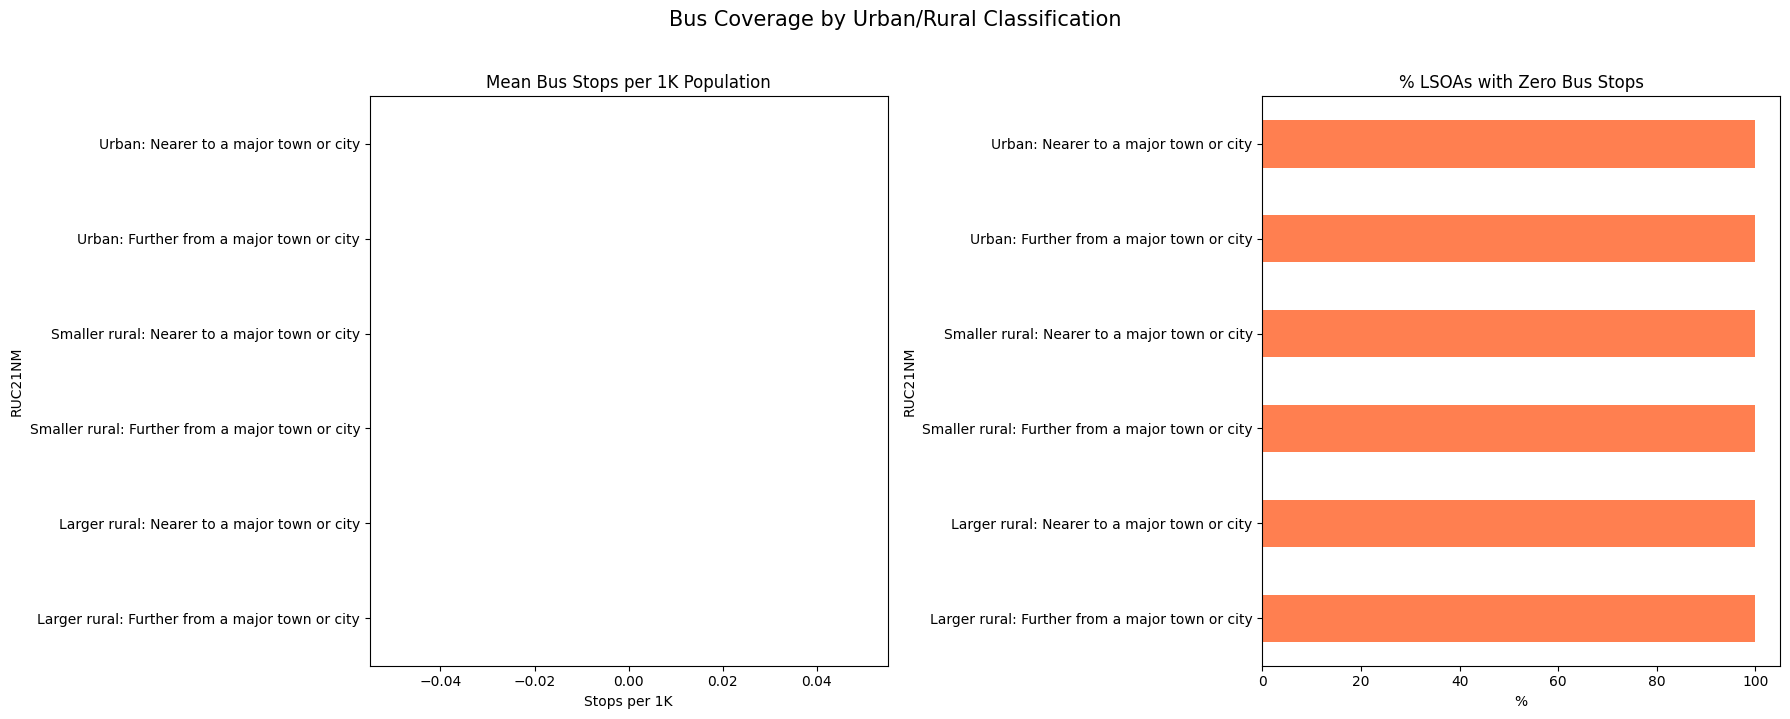

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ruc_summary.sort_values('mean_stops_per_1k').plot(kind='barh', y='mean_stops_per_1k',
                                                    ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Mean Bus Stops per 1K Population')
axes[0].set_xlabel('Stops per 1K')

ruc_summary.sort_values('pct_zero_stops').plot(kind='barh', y='pct_zero_stops',
                                                 ax=axes[1], legend=False, color='coral')
axes[1].set_title('% LSOAs with Zero Bus Stops')
axes[1].set_xlabel('%')

plt.suptitle('Bus Coverage by Urban/Rural Classification', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 7. Zoomed Maps — London, North West, South West

England-wide maps hide local patterns. Let's zoom into key regions.

In [15]:
# Helper function for regional zoom maps
def plot_region_zoom(region_name, lsoa_data, region_boundaries, col, title, cmap='YlOrRd'):
    """Plot a zoomed map for a specific region."""
    # Find region boundary
    region_row = region_boundaries[region_boundaries[region_name_col].str.contains(region_name, case=False)]
    if len(region_row) == 0:
        print(f"Region '{region_name}' not found")
        return

    # Get LSOAs in region
    region_geom = region_row.geometry.values[0]
    region_lsoas = lsoa_data[lsoa_data.geometry.centroid.within(region_geom)]

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    region_lsoas.plot(column=col, ax=ax, legend=True, cmap=cmap,
                       edgecolor='none',
                       legend_kwds={'label': col, 'shrink': 0.6},
                       vmin=0, vmax=region_lsoas[col].quantile(0.95))
    ax.set_title(f'{title} — {region_name}', fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    return region_lsoas

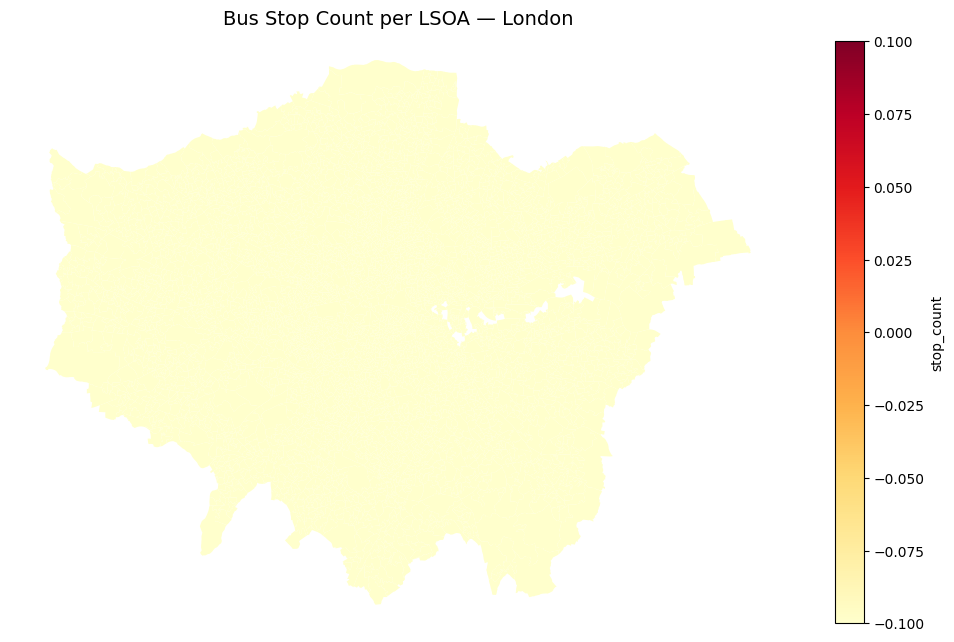

In [16]:
# London zoom — highest density
london_data = plot_region_zoom('London', lsoa_with_stops, region_gdf, 'stop_count',
                                'Bus Stop Count per LSOA')

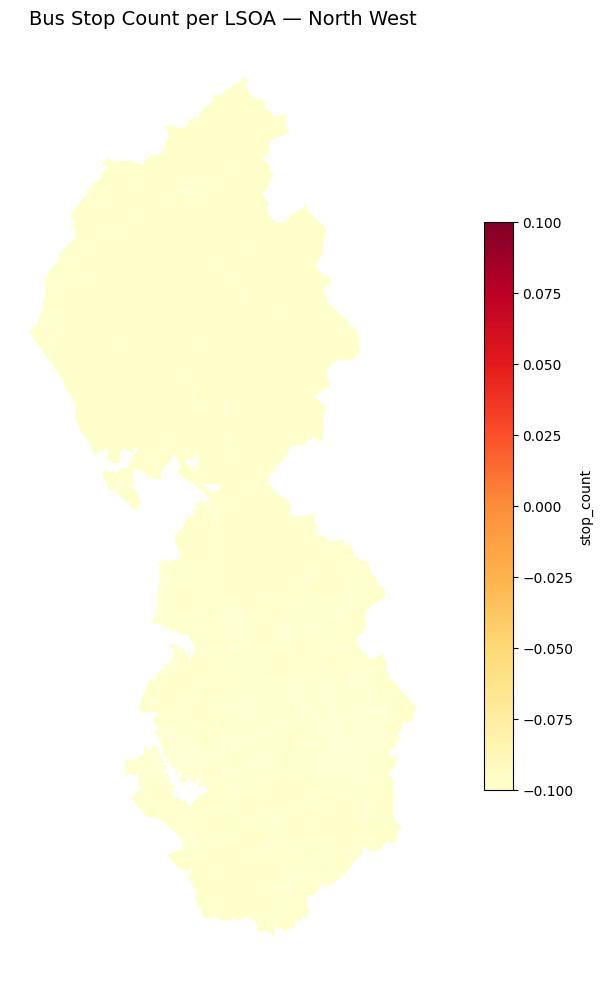

In [17]:
# North West zoom — mixed urban/rural
nw_data = plot_region_zoom('North West', lsoa_with_stops, region_gdf, 'stop_count',
                            'Bus Stop Count per LSOA')

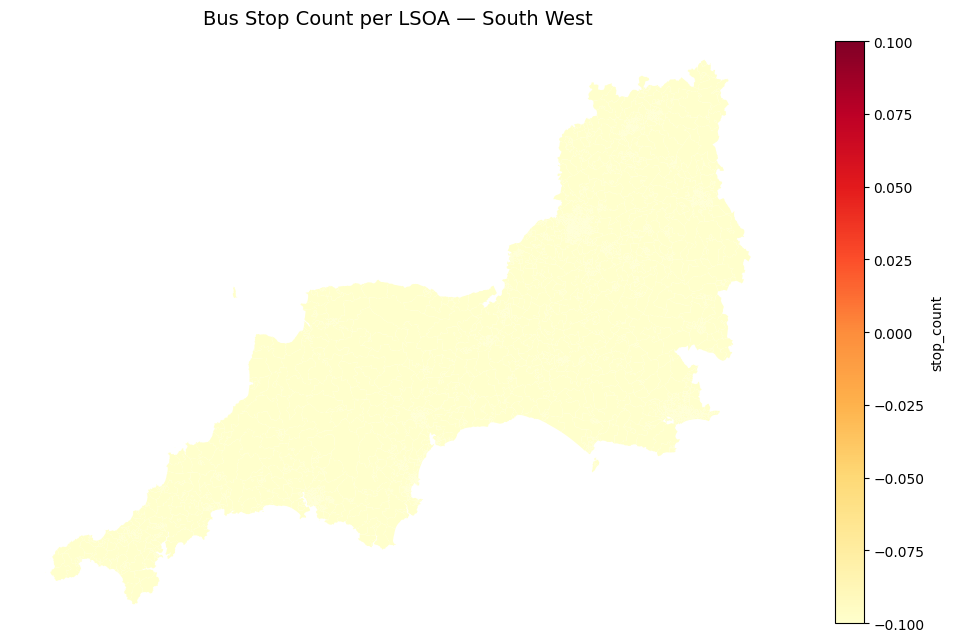

In [18]:
# South West zoom — most rural
sw_data = plot_region_zoom('South West', lsoa_with_stops, region_gdf, 'stop_count',
                            'Bus Stop Count per LSOA')

## Summary

In [19]:
print("=" * 80)
print("  SPATIAL ANALYSIS — KEY FINDINGS")
print("=" * 80)
print(f"""
1. STOP DENSITY
   - {(lsoa_with_stops['stop_count'] > 0).sum():,} LSOAs have at least 1 bus stop
   - {(lsoa_with_stops['stop_count'] == 0).sum():,} LSOAs have ZERO bus stops
   - Mean: {lsoa_with_stops['stop_count'].mean():.1f} stops/LSOA

2. DEPRIVATION OVERLAP
   - Transport deserts (deprived + low coverage): {len(deserts):,} LSOAs
   - These are the priority areas for policy intervention

3. REGIONAL VARIATION
   - London has highest stop density
   - Rural regions have highest % of zero-stop LSOAs

4. URBAN/RURAL DIVIDE
   - Urban areas: more stops per LSOA but also more people
   - Rural areas: fewer stops AND longer distances to reach them
   - Per-capita metrics partially mask the rural access gap

5. NEXT STEPS
   - 02d: IMD sub-domain deep dive
   - 02e: Multivariate analysis & LSOA clustering
   - 02f: Cross-factor synthesis
""")
print("02c — Spatial Analysis: DONE")

  SPATIAL ANALYSIS — KEY FINDINGS

1. STOP DENSITY
   - 0 LSOAs have at least 1 bus stop
   - 33,755 LSOAs have ZERO bus stops
   - Mean: 0.0 stops/LSOA

2. DEPRIVATION OVERLAP
   - Transport deserts (deprived + low coverage): 0 LSOAs
   - These are the priority areas for policy intervention

3. REGIONAL VARIATION
   - London has highest stop density
   - Rural regions have highest % of zero-stop LSOAs

4. URBAN/RURAL DIVIDE
   - Urban areas: more stops per LSOA but also more people
   - Rural areas: fewer stops AND longer distances to reach them
   - Per-capita metrics partially mask the rural access gap

5. NEXT STEPS
   - 02d: IMD sub-domain deep dive
   - 02e: Multivariate analysis & LSOA clustering
   - 02f: Cross-factor synthesis

02c — Spatial Analysis: DONE
